# **Install required packages**


In [ ]:
!pip install lightgbm -q
print("Setup done!")

Setup done!


# **Verifying upload**

In [ ]:
import os
for f in os.listdir():
    if f.endswith('.csv'):
        print(f)

train-test.csv
december-chart-inputs.csv
validation.csv
validation-predictions-template.csv


# **Data Loading & Sanity Checks**

In [ ]:
import pandas as pd
import numpy as np

# Load datasets
train_test = pd.read_csv('train-test.csv')
validation = pd.read_csv('validation.csv')
val_template = pd.read_csv('validation-predictions-template.csv')
december = pd.read_csv('december-chart-inputs.csv')

print("train_test shape:", train_test.shape)
print("validation shape:", validation.shape)
print("val_template shape:", val_template.shape)
print("december shape:", december.shape)

train_test shape: (48000, 14)
validation shape: (12000, 13)
val_template shape: (12000, 2)
december shape: (31, 7)


# **Checking data types and missing values**

In [ ]:
print("=== train_test info ===")
print(train_test.dtypes)
print("\n=== Missing values in train_test ===")
print(train_test.isna().sum())
print("\n=== Missing values in validation ===")
print(validation.isna().sum())

=== train_test info ===
load_id          object
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
date             object
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object

=== Missing values in train_test ===
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

=== Missing values in validation ===
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal     

# **Checking for duplicate IDs and categorical distributions**

In [ ]:
print("Duplicate load_id in train_test:", train_test['load_id'].duplicated().sum())
print("Duplicate load_id in validation:", validation['load_id'].duplicated().sum())

print("\n=== Equipment types (train_test) ===")
print(train_test['equipment'].value_counts())

print("\n=== Equipment types (validation) ===")
print(validation['equipment'].value_counts())

print("\n=== Date range train_test ===")
print(train_test['date'].min(), "to", train_test['date'].max())

print("\n=== Date range validation ===")
print(validation['date'].min(), "to", validation['date'].max())

Duplicate load_id in train_test: 0
Duplicate load_id in validation: 0

=== Equipment types (train_test) ===
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

=== Equipment types (validation) ===
equipment
Dry Van    6780
Reefer     3051
Flatbed    2169
Name: count, dtype: int64

=== Date range train_test ===
2025-01-01 to 2025-10-31

=== Date range validation ===
2025-11-01 to 2025-12-31


# **Exploratory Data Analysis (EDA)**

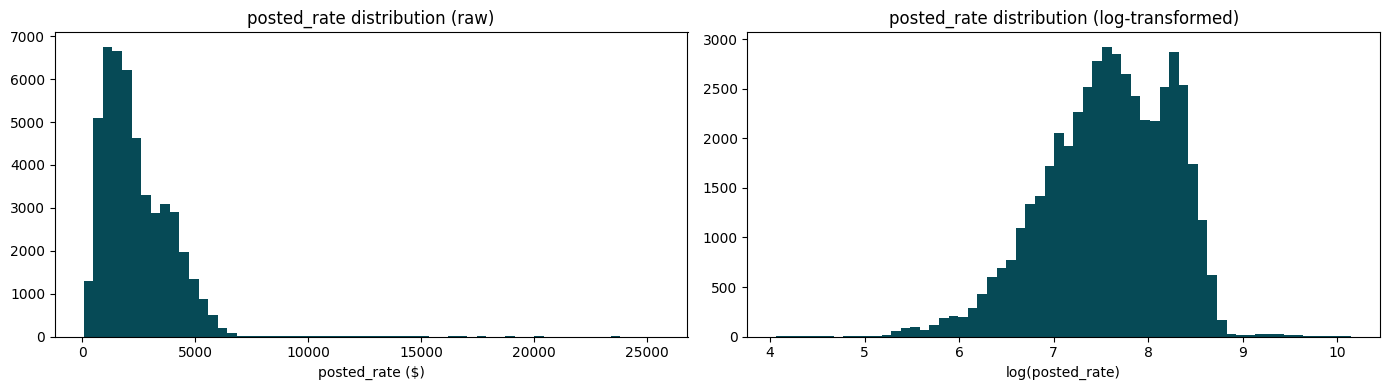

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_test['posted_rate'], bins=60, color='#064A56')
axes[0].set_title('posted_rate distribution (raw)')
axes[0].set_xlabel('posted_rate ($)')

axes[1].hist(np.log1p(train_test['posted_rate']), bins=60, color='#064A56')
axes[1].set_title('posted_rate distribution (log-transformed)')
axes[1].set_xlabel('log(posted_rate)')

plt.tight_layout()
plt.show()

print(train_test['posted_rate'].describe())

# **Relationship between posted_rate and key features**

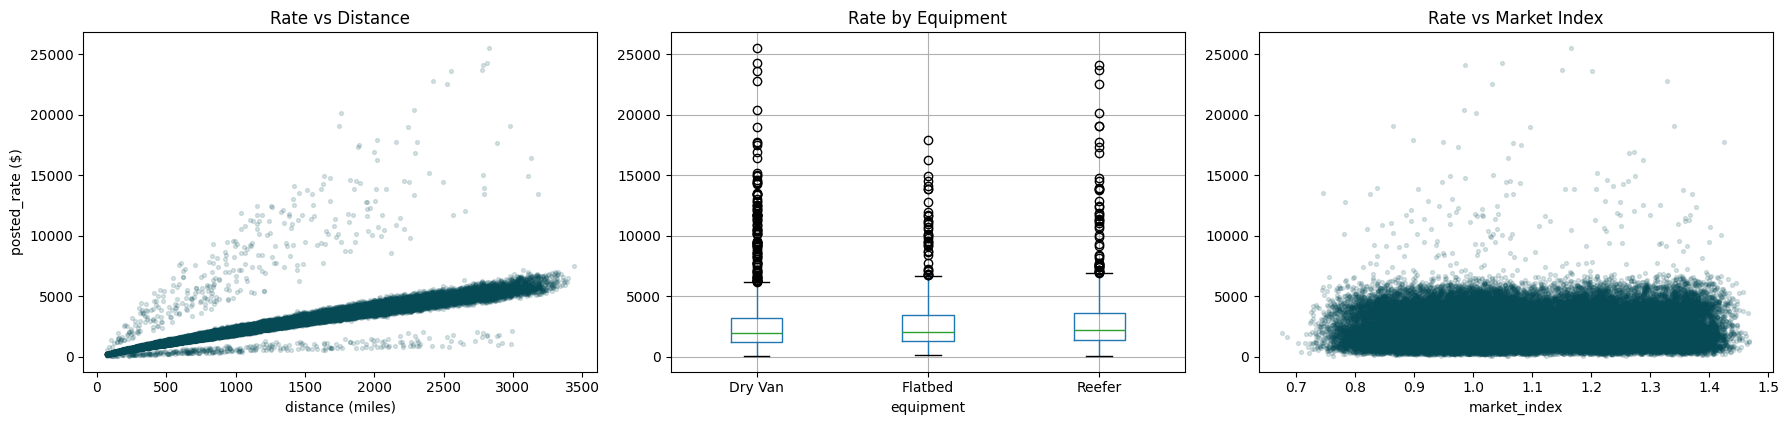

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Rate vs Distance
axes[0].scatter(train_test['distance'], train_test['posted_rate'], alpha=0.15, s=8, color='#064A56')
axes[0].set_xlabel('distance (miles)')
axes[0].set_ylabel('posted_rate ($)')
axes[0].set_title('Rate vs Distance')

# Rate by Equipment (boxplot)
train_test.boxplot(column='posted_rate', by='equipment', ax=axes[1])
axes[1].set_title('Rate by Equipment')
axes[1].set_xlabel('equipment')
plt.suptitle('')

# Rate vs market_index
axes[2].scatter(train_test['market_index'], train_test['posted_rate'], alpha=0.15, s=8, color='#064A56')
axes[2].set_xlabel('market_index')
axes[2].set_title('Rate vs Market Index')

plt.tight_layout()
plt.show()

# **Checking lane-level pricing and seasonality**

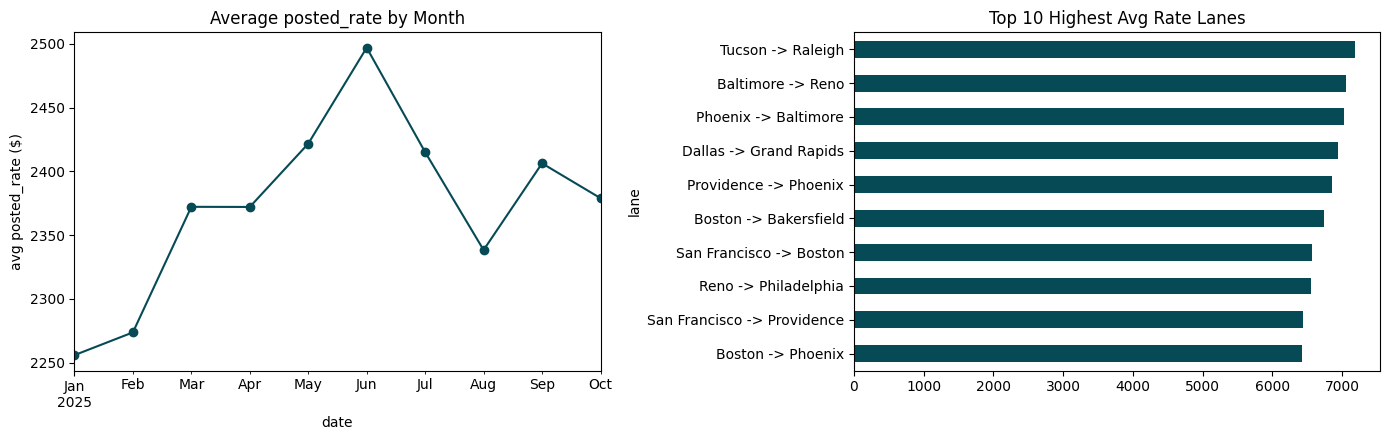

Number of unique lanes: 4014


In [ ]:
train_test['date'] = pd.to_datetime(train_test['date'])

monthly_avg = train_test.groupby(train_test['date'].dt.to_period('M'))['posted_rate'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

monthly_avg.plot(kind='line', marker='o', ax=axes[0], color='#064A56')
axes[0].set_title('Average posted_rate by Month')
axes[0].set_ylabel('avg posted_rate ($)')

train_test['lane'] = train_test['pickup'] + ' -> ' + train_test['delivery']
lane_avg = train_test.groupby('lane')['posted_rate'].mean().sort_values(ascending=False).head(10)
lane_avg.plot(kind='barh', ax=axes[1], color='#064A56')
axes[1].set_title('Top 10 Highest Avg Rate Lanes')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Number of unique lanes:", train_test['lane'].nunique())

# **Data Cleaning**

In [ ]:
weight_median = train_test['weight'].median()
market_index_median = train_test['market_index'].median()

print("Weight median:", weight_median)
print("Market index median:", market_index_median)

train_test['weight'] = train_test['weight'].fillna(weight_median)
train_test['market_index'] = train_test['market_index'].fillna(market_index_median)

validation['weight'] = validation['weight'].fillna(weight_median)
validation['market_index'] = validation['market_index'].fillna(market_index_median)

print("\nRemaining missing values in train_test:")
print(train_test[['weight', 'market_index']].isna().sum())
print("\nRemaining missing values in validation:")
print(validation[['weight', 'market_index']].isna().sum())

Weight median: 31436.5
Market index median: 1.0558

Remaining missing values in train_test:
weight          0
market_index    0
dtype: int64

Remaining missing values in validation:
weight          0
market_index    0
dtype: int64


# **Feature Engineering**

In [ ]:
import numpy as np

def add_date_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_year'] = df['date'].dt.dayofyear
    return df

def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8  # miles
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def add_geo_features(df):
    df = df.copy()
    df['haversine_distance'] = haversine(df['pickup_lat'], df['pickup_lon'],
                                          df['delivery_lat'], df['delivery_lon'])
    df['distance_diff'] = df['distance'] - df['haversine_distance']
    return df

train_test = add_date_features(train_test)
train_test = add_geo_features(train_test)

validation = add_date_features(validation)
validation = add_geo_features(validation)

print(train_test[['date', 'month', 'day_of_week', 'day_of_year',
                   'distance', 'haversine_distance', 'distance_diff']].head())
print("\nDistance diff stats (train_test):")
print(train_test['distance_diff'].describe())

        date  month  day_of_week  day_of_year  distance  haversine_distance  \
0 2025-01-01      1            2            1     274.3          219.808768   
1 2025-01-01      1            2            1     280.5          220.525617   
2 2025-01-01      1            2            1     967.8          826.919847   
3 2025-01-01      1            2            1     965.4          840.540749   
4 2025-01-01      1            2            1     541.9          434.163187   

   distance_diff  
0      54.491232  
1      59.974383  
2     140.880153  
3     124.859251  
4     107.736813  

Distance diff stats (train_test):
count    48000.000000
mean       169.702294
std        100.072162
min          4.556779
25%         90.741713
50%        144.212569
75%        234.160251
max        581.665453
Name: distance_diff, dtype: float64


# **Encoding categorical features**

In [ ]:
categorical_cols = ['pickup', 'delivery', 'equipment']

for col in categorical_cols:
    train_test[col] = train_test[col].astype('category')
    validation[col] = validation[col].astype('category')

for col in categorical_cols:
    validation[col] = validation[col].cat.set_categories(train_test[col].cat.categories)

print(train_test[categorical_cols].dtypes)
print("\nSample categories (equipment):", train_test['equipment'].cat.categories.tolist())

pickup       category
delivery     category
equipment    category
dtype: object

Sample categories (equipment): ['Dry Van', 'Flatbed', 'Reefer']


# **Train/Validation Split**

In [ ]:
split_date = '2025-09-01'

train_set = train_test[train_test['date'] < split_date].copy()
val_set = train_test[train_test['date'] >= split_date].copy()

print("Train set:", train_set.shape, "| date range:", train_set['date'].min(), "to", train_set['date'].max())
print("Val set:  ", val_set.shape, "| date range:", val_set['date'].min(), "to", val_set['date'].max())
print("\nTrain %:", round(len(train_set)/len(train_test)*100, 1))
print("Val %:  ", round(len(val_set)/len(train_test)*100, 1))

Train set: (38477, 20) | date range: 2025-01-01 00:00:00 to 2025-08-31 00:00:00
Val set:   (9523, 20) | date range: 2025-09-01 00:00:00 to 2025-10-31 00:00:00

Train %: 80.2
Val %:   19.8


# **Baseline Model — Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

feature_cols = ['pickup', 'delivery', 'distance', 'equipment', 'weight',
                 'market_index', 'quote_signal', 'month', 'day_of_week', 'day_of_year']

X_train = train_set[feature_cols]
y_train = np.log1p(train_set['posted_rate'])

X_val = val_set[feature_cols]
y_val = val_set['posted_rate']

categorical_features = ['pickup', 'delivery', 'equipment']
numeric_features = [c for c in feature_cols if c not in categorical_features]

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

baseline_model = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])

baseline_model.fit(X_train, y_train)

val_pred_log = baseline_model.predict(X_val)
val_pred = np.expm1(val_pred_log)

mae = mean_absolute_error(y_val, val_pred)
rmse = np.sqrt(mean_squared_error(y_val, val_pred))
mape = np.mean(np.abs((y_val - val_pred) / y_val)) * 100
r2 = r2_score(y_val, val_pred)

print("=== Baseline (Linear Regression) — Internal Validation ===")
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²:   {r2:.4f}")

=== Baseline (Linear Regression) — Internal Validation ===
MAE:  $432.64
RMSE: $894.80
MAPE: 20.55%
R²:   0.6562


# **Main Model — LightGBM**

In [ ]:
import lightgbm as lgb

X_train_lgb = train_set[feature_cols].copy()
X_val_lgb = val_set[feature_cols].copy()

for col in categorical_features:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_val_lgb[col] = X_val_lgb[col].astype('category')

y_train_log = np.log1p(train_set['posted_rate'])
y_val_raw = val_set['posted_rate']

lgb_train = lgb.Dataset(X_train_lgb, label=y_train_log, categorical_feature=categorical_features)
lgb_val = lgb.Dataset(X_val_lgb, label=np.log1p(y_val_raw), categorical_feature=categorical_features, reference=lgb_train)

params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'seed': 42
}

lgb_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

val_pred_log_lgb = lgb_model.predict(X_val_lgb, num_iteration=lgb_model.best_iteration)
val_pred_lgb = np.expm1(val_pred_log_lgb)

mae_lgb = mean_absolute_error(y_val_raw, val_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_val_raw, val_pred_lgb))
mape_lgb = np.mean(np.abs((y_val_raw - val_pred_lgb) / y_val_raw)) * 100
r2_lgb = r2_score(y_val_raw, val_pred_lgb)

print("\n=== LightGBM — Internal Validation ===")
print(f"MAE:  ${mae_lgb:.2f}")
print(f"RMSE: ${rmse_lgb:.2f}")
print(f"MAPE: {mape_lgb:.2f}%")
print(f"R²:   {r2_lgb:.4f}")

print("\n=== Comparison ===")
print(f"Baseline (Linear) MAE: ${mae:.2f}  |  LightGBM MAE: ${mae_lgb:.2f}")
print(f"Baseline (Linear) R²:  {r2:.4f}    |  LightGBM R²:  {r2_lgb:.4f}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 0.047101
Early stopping, best iteration is:
[108]	valid_0's l1: 0.0470416

=== LightGBM — Internal Validation ===
MAE:  $123.82
RMSE: $638.60
MAPE: 5.31%
R²:   0.8249

=== Comparison ===
Baseline (Linear) MAE: $432.64  |  LightGBM MAE: $123.82
Baseline (Linear) R²:  0.6562    |  LightGBM R²:  0.8249


# **Feature Importance**

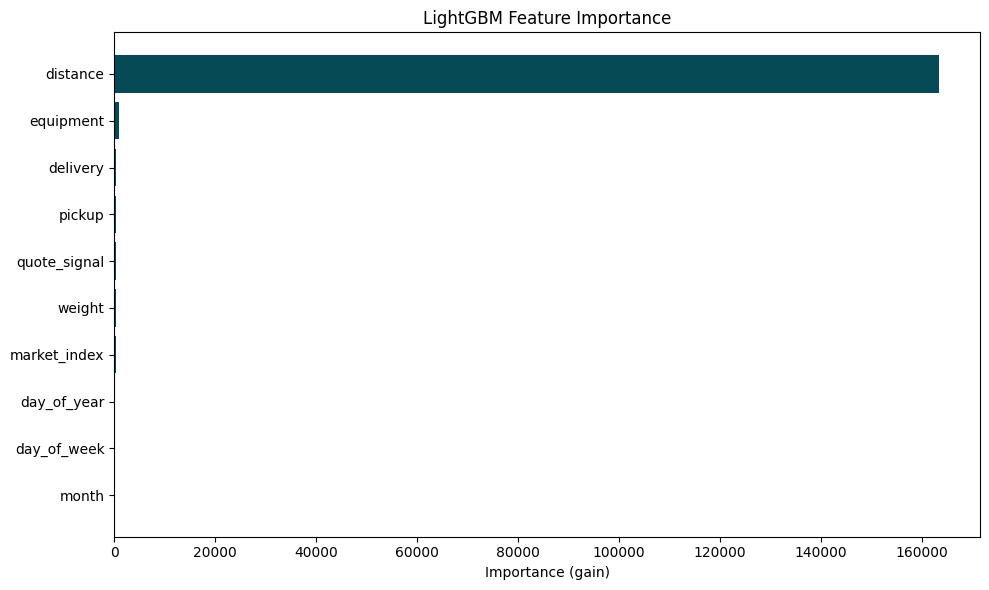

        feature     importance
2      distance  163367.974925
3     equipment     992.221248
1      delivery     425.226244
0        pickup     419.730597
6  quote_signal     324.891136
4        weight     300.809844
5  market_index     297.548555
9   day_of_year     199.246517
8   day_of_week      13.060751
7         month       9.594659


In [ ]:
importance_df = pd.DataFrame({
    'feature': lgb_model.feature_name(),
    'importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='#064A56')
plt.gca().invert_yaxis()
plt.xlabel('Importance (gain)')
plt.title('LightGBM Feature Importance')
plt.tight_layout()
plt.show()

print(importance_df)

# **Final Model Training**

In [ ]:
X_full = train_test[feature_cols].copy()
for col in categorical_features:
    X_full[col] = X_full[col].astype('category')
y_full_log = np.log1p(train_test['posted_rate'])

lgb_full_train = lgb.Dataset(X_full, label=y_full_log, categorical_feature=categorical_features)

final_model = lgb.train(
    params,
    lgb_full_train,
    num_boost_round=lgb_model.best_iteration
)

print("Final model trained on", len(X_full), "rows")
print("Boost rounds used:", lgb_model.best_iteration)

Final model trained on 48000 rows
Boost rounds used: 108


# **Prediction**

In [ ]:
X_validation_final = validation[feature_cols].copy()
for col in categorical_features:
    X_validation_final[col] = X_validation_final[col].astype('category')

pred_log = final_model.predict(X_validation_final)
predicted_rate = np.expm1(pred_log)

val_template_filled = val_template.copy()
val_template_filled['predicted_rate'] = predicted_rate.round(2)

print("Shape:", val_template_filled.shape)
print("Any missing:", val_template_filled['predicted_rate'].isna().sum())
print("Any non-positive:", (val_template_filled['predicted_rate'] <= 0).sum())
print(val_template_filled.head())

val_template_filled.to_csv('validation_predictions.csv', index=False)
print("\nSaved: validation_predictions.csv")

Shape: (12000, 2)
Any missing: 0
Any non-positive: 0
     load_id  predicted_rate
0  TE-000001          837.53
1  TE-000002         4958.44
2  TE-000003         5222.66
3  TE-000004         4049.09
4  TE-000005         1808.61

Saved: validation_predictions.csv


# **Predicting on december-chart**

In [ ]:
december_features = add_date_features(december)


december_features['market_index'] = market_index_median
december_features['quote_signal'] = train_test['quote_signal'].median()

X_december = december_features[feature_cols].copy()
for col in categorical_features:
    X_december[col] = X_december[col].astype('category').cat.set_categories(train_test[col].cat.categories)

dec_pred_log = final_model.predict(X_december)
december_features['predicted_rate'] = np.expm1(dec_pred_log).round(2)

december_final = december_features[['pickup', 'delivery', 'distance', 'equipment',
                                      'weight', 'date', 'predicted_rate']].copy()
december_final['date'] = december_final['date'].dt.strftime('%Y-%m-%d')

print(december_final)
december_final.to_csv('december_chart_inputs.csv', index=False)
print("\nSaved: december_chart_inputs.csv")

       pickup    delivery  distance equipment  weight        date  \
0   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-01   
1   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-02   
2   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-03   
3   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-04   
4   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-05   
5   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-06   
6   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-07   
7   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-08   
8   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-09   
9   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-10   
10  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-11   
11  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-12   
12  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-13   
13  Lexington  Fort Wayne       36

# **Checking whether day-of-week affects rate in training data**

day_of_week
0    2349.308676
1    2372.890626
2    2405.086706
3    2403.265599
4    2376.849855
5    2373.714334
6    2335.073176
Name: posted_rate, dtype: float64


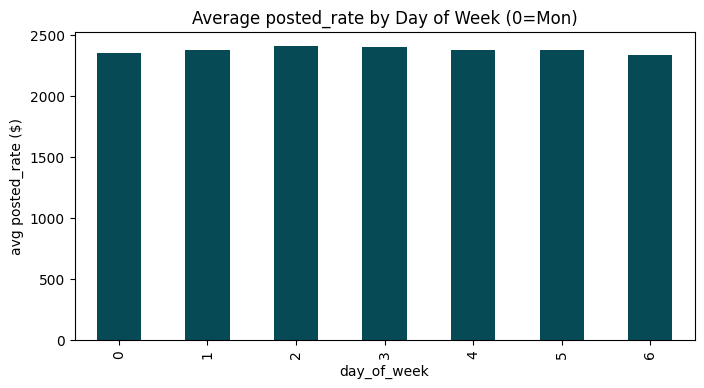

In [ ]:
dow_avg = train_test.groupby('day_of_week')['posted_rate'].mean()
print(dow_avg)

plt.figure(figsize=(8,4))
dow_avg.plot(kind='bar', color='#064A56')
plt.title('Average posted_rate by Day of Week (0=Mon)')
plt.ylabel('avg posted_rate ($)')
plt.show()

# **Download Submission Files**

In [ ]:
from google.colab import files
files.download('validation_predictions.csv')
files.download('december_chart_inputs.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Files upload**

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving requirements.txt to requirements.txt
Saving readme.md to readme.md
Saving score.py to score.py


# **`Score.py run`**

In [ ]:
import os

os.makedirs('data', exist_ok=True)

if os.path.exists('december_chart_inputs.csv'):
    os.rename('december_chart_inputs.csv', 'data/december_chart_inputs.csv')

!pip install -r requirements.txt -q

!python score.py --predictions validation_predictions.csv --december-predictions data/december_chart_inputs.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


# **Viewing & downloading the chart**

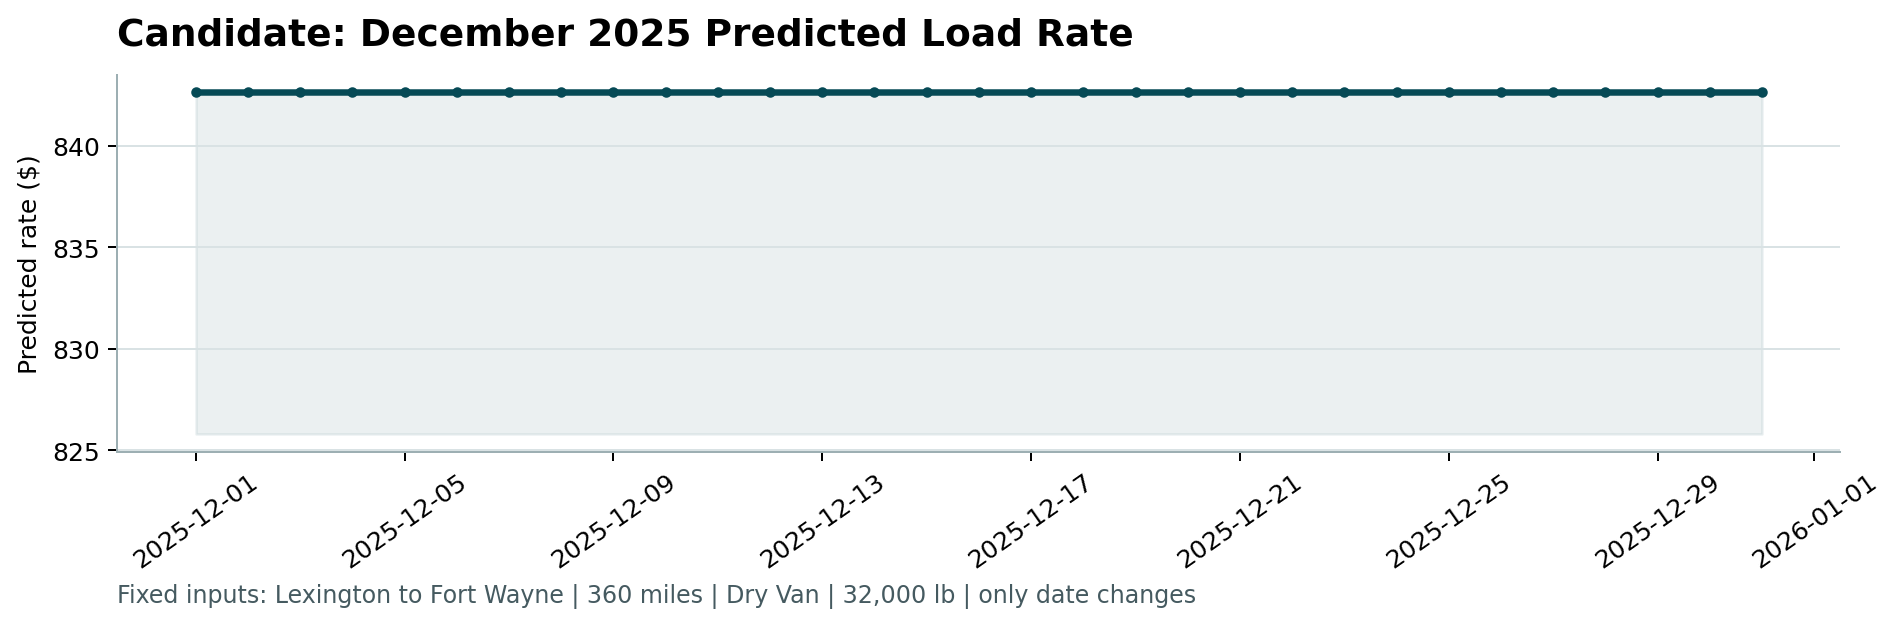

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files


from IPython.display import Image, display
display(Image('scorer_results/candidate_december.png'))


files.download('scorer_results/candidate_december.png')